# **ZADANIE 2**

## IMIE: Małgorzata
## NAZWISKO: Bondini

## WAZNE: prosze zmienic nazwe notatnika na: "Nazwisko_Imie_MAD_ZadaniePraktyczne02"


## **ZADANIE: Dla zbioru danych dotyczącego cukrzycy zbuduj model regresyjny do przewidywania postępu choroby rok po wartości początkowej:**

    1. Zbadaj zbiór danych:
        Wyświetl pierwsze kilka wierszy zbioru danych
        Wyświetl statystyki opisowe zbioru danych
        Narysuj wykres rozkładu zmiennej docelowej

    2. Wydziel zbiór testowy i treningowy

    3. Przeskaluj dane i oblicz średni współczynnik ( R^2 ) przy użyciu walidacji krzyżowej dla modeli:

        Regresja grzbietowa (Ridge) z alpha = 1, 0.01

        Regresja LASSO z alpha = 1, 0.01

        Las losowy z parametrami: n_estimators = 100, 200;

    3. Porównaj wyniki, wybierz najlepszy model

    4. przetrenój finalny model na wszytskich danych treningowych i oblicz współczynnik ( R^2 ) dla zbioru testowego. (pamietaj o skalowaniu)

    5. Narysuj wykres reszt (residuals) dla najlepszego modelu na zbiorze testowym (eg. scatter plot y_true-y_pred vs y_True)

**Informacje o zbiorze danych dotyczącego cukrzycy**

Zbiór danych dotyczący cukrzycy jest klasycznym zbiorem danych używanym w zadaniach regresji. Zawiera 10 zmiennych bazowych takich jak: wiek, płeć, wskaźnik masy ciała (BMI), średnie ciśnienie krwi oraz sześć pomiarów surowicy krwi, uzyskanych dla 442 pacjentów z cukrzycą, a także zmienną docelową (y), czyli ilościowy wskaźnik postępu choroby rok po wartości początkowej.Jest on dostepny jako zestaw danych w bibliotece sklearn.

## TIP's

### How to compare models
* Regression: R^2 (score method)
* Classification: Accuracy (score method)

## ZANIM ZACZNIECIE KODOWAC ODPOWIEDZCIE SOBIE NA TE PYTANIA
"uporzadkujcie swoj projekt, przykladowe pytania i zagadnienia sa pod kazdym punktem"

* __jakie sa pytania lub zadania?__
* __jakie mamy dane?__
* __jakiego modelu chcecie uzyc?__
* __jak wykonac trenowanie?__
* __jak wykonamy podsumowanie?__

"""
### Order of things
* Imports
* Load the data
* Find ( X ), ( y )
* Explore ( X ) and ( y )
* Format ( X ) and ( y ), EG, AS INTEGERS, alwasy try to make it work with min. work, later on, make it more complicicated
* scale if needed, add or remove missing data , USE PILEINE IF NEEDED,
* Split into test and train sets
* List models you will use and all their parameters that you wish to modify
* Train models one by one and evaluate using cross-validation
* Select the best model
* retrain best performing model with all the train data (so far these were used for cross validation)
* Evaluate on the test data
* Report the results
"""

KODOWANIE

In [70]:
"""
### Order of things
* Imports
* Load the data
* Find ( X ), ( y )
* Explore ( X ) and ( y )
* Format ( X ) and ( y ), EG, AS INTEGERS, alwasy try to make it work with min. work, later on, make it more complicicated
* scale if needed, add or remove missing data , USE PILEINE IF NEEDED,
* Split into test and train sets
* List models you will use and all their parameters that you wish to modify
* Train models one by one and evaluate using cross-validation
* Select the best model
* retrain best performing model with all the train data (so far these were used for cross validation)
* Evaluate on the test data
* Report the results
"""

'\n### Order of things\n* Imports\n* Load the data\n* Find ( X ), ( y )\n* Explore ( X ) and ( y )\n* Format ( X ) and ( y ), EG, AS INTEGERS, alwasy try to make it work with min. work, later on, make it more complicicated\n* scale if needed, add or remove missing data , USE PILEINE IF NEEDED,\n* Split into test and train sets\n* List models you will use and all their parameters that you wish to modify\n* Train models one by one and evaluate using cross-validation\n* Select the best model\n* retrain best performing model with all the train data (so far these were used for cross validation)\n* Evaluate on the test data\n* Report the results\n'

---
# *Pytania przed analizą:*

### Co chcemy przewidzieć?
Postęp cukrzycy typu 2. Czyli regresja, nie klasyfikacja.

### Jakie są dane?
Dane ilościowe i medyczne, posep choroby.

### Jakich modeli użyć?
Ridge, LASSO (liniowe) i Random Forest (nieliniowy), łącznie 6 wariantów.

### Jak najlepiej trenować model?
Podział 80/20, walidacja krzyżowa 5-fold z Pipeline (skalowanie + model).

### Jak ocenić, który model jest najlepszy?
Metryka R² i im wyższe, tym lepiej. Najlepszy testować na zbiorze testowym.

---
## Importy bibliotek

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Wizualizacje
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

In [ ]:
# load data
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="target")

### 1.2 Pierwsze wiersze zbioru danych

Podgląd pierwszych 10 wierszy.

In [45]:
X.head(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
5,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041176,-0.096346
6,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357
7,0.063504,0.050680,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064
8,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504


### 1.3 Statystyki opisowe X

Znormalizowane średnie powinny być bliskie 0.

In [46]:
X.describe().round(4)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000,442.0000
mean,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000
std,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476,0.0476
min,-0.1072,-0.0446,-0.0903,-0.1124,-0.1268,-0.1156,-0.1023,-0.0764,-0.1261,-0.1378
25%,-0.0373,-0.0446,-0.0342,-0.0367,-0.0342,-0.0304,-0.0351,-0.0395,-0.0332,-0.0332
50%,0.0054,-0.0446,-0.0073,-0.0057,-0.0043,-0.0038,-0.0066,-0.0026,-0.0019,-0.0011
75%,0.0381,0.0507,0.0312,0.0356,0.0284,0.0298,0.0293,0.0343,0.0324,0.0279
max,0.1107,0.0507,0.1706,0.1320,0.1539,0.1988,0.1812,0.1852,0.1336,0.1356


### 1.4 Statystyki (y)

Zmienna `y` to postęp cukrzycy.

In [47]:
print(y.describe().round(2))
print(f"Zakres: {y.min():.0f} – {y.max():.0f}")

count    442.00
mean     152.13
std       77.09
min       25.00
25%       87.00
50%      140.50
75%      211.50
max      346.00
Name: target, dtype: float64
Zakres: 25 – 346


### 1.5 Sprawdzenie braków danych

(NaN) do wywalenia

In [48]:
missing = X.isnull().sum().sum() + y.isnull().sum()
print(f"Łączna liczba braków danych: {missing}")
if missing == 0:
    print("Dane są kompletne")
else:
    print("Znaleziono braki danych")

Łączna liczba braków danych: 0
Dane są kompletne


### 1.6 Rozkład zmiennej (y)

- **Kształt rozkładu**
- **Outliers**
- **Zróżnicowanie**

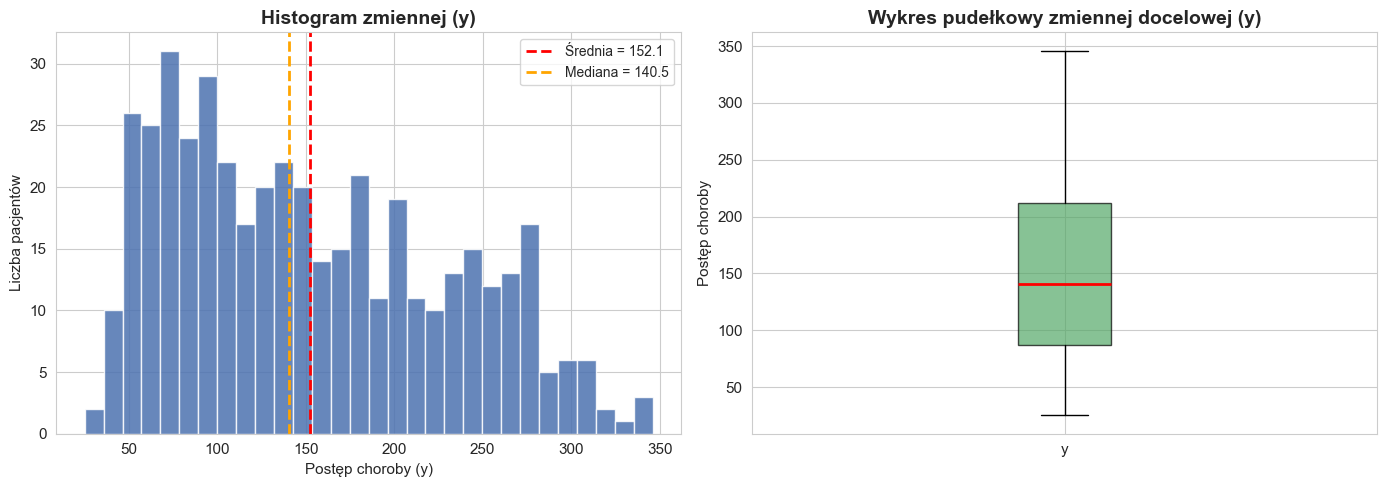

Większość pacjentów ma niski postęp choroby.
Średnia jest zwykle wyższa niż mediana, a nich model może częściej popełniać większe błędy.


In [49]:
mean_y = np.mean(y)
median_y = np.median(y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y, bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].axvline(mean_y, color="red", linestyle="--", linewidth=2, label=f"Średnia = {mean_y:.1f}")
axes[0].axvline(median_y, color="orange", linestyle="--", linewidth=2, label=f"Mediana = {median_y:.1f}")
axes[0].set_title("Histogram zmiennej (y)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Postęp choroby (y)")
axes[0].set_ylabel("Liczba pacjentów")
axes[0].legend(fontsize=10)

axes[1].boxplot(
    y,
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="#55A868", alpha=0.7),
    medianprops=dict(color="red", linewidth=2)
)
axes[1].set_title("Wykres pudełkowy zmiennej docelowej (y)", fontsize=14, fontweight="bold")
axes[1].set_ylabel("Postęp choroby")
axes[1].set_xticklabels(["y"])

plt.tight_layout()
plt.show()

print("Większość pacjentów ma niski postęp choroby.")
print("Średnia jest zwykle wyższa niż mediana, a nich model może częściej popełniać większe błędy.")

# Wnioski: Połowa pacjentów mieści się w tym zakresie. Brak wyraźnych outlierów, co oznacza, że nie ma ekstremalnych wartości odstających.

### Rozkłady poszczególnych cech (X)

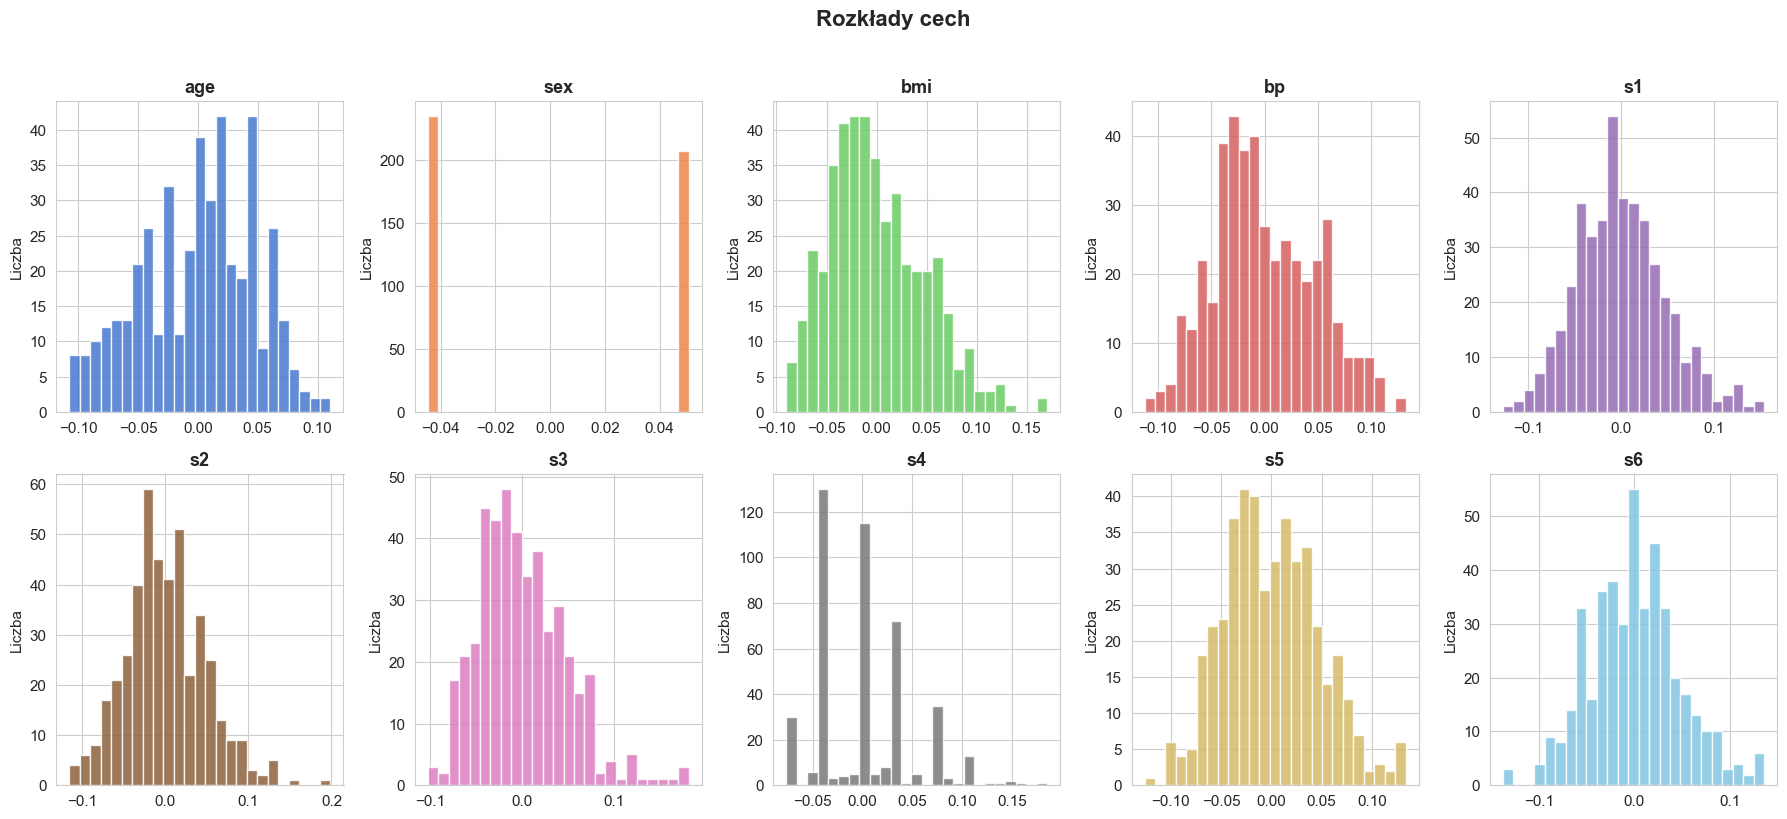

In [50]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

colors = sns.color_palette("muted", 10)

for i, col in enumerate(X.columns):
    axes[i].hist(X[col], bins=25, color=colors[i], edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=13, fontweight="bold")
    axes[i].set_ylabel("Liczba")

plt.suptitle("Rozkłady cech", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Wnioski: Ogólnie: dane wyglądają czysto, nie trzeba nic specjalnie naprawiać przed modelowaniem.

### 1.8 Macierz korelacji

- **Które cechy są najsilniej skorelowane z postępem choroby (Y)?

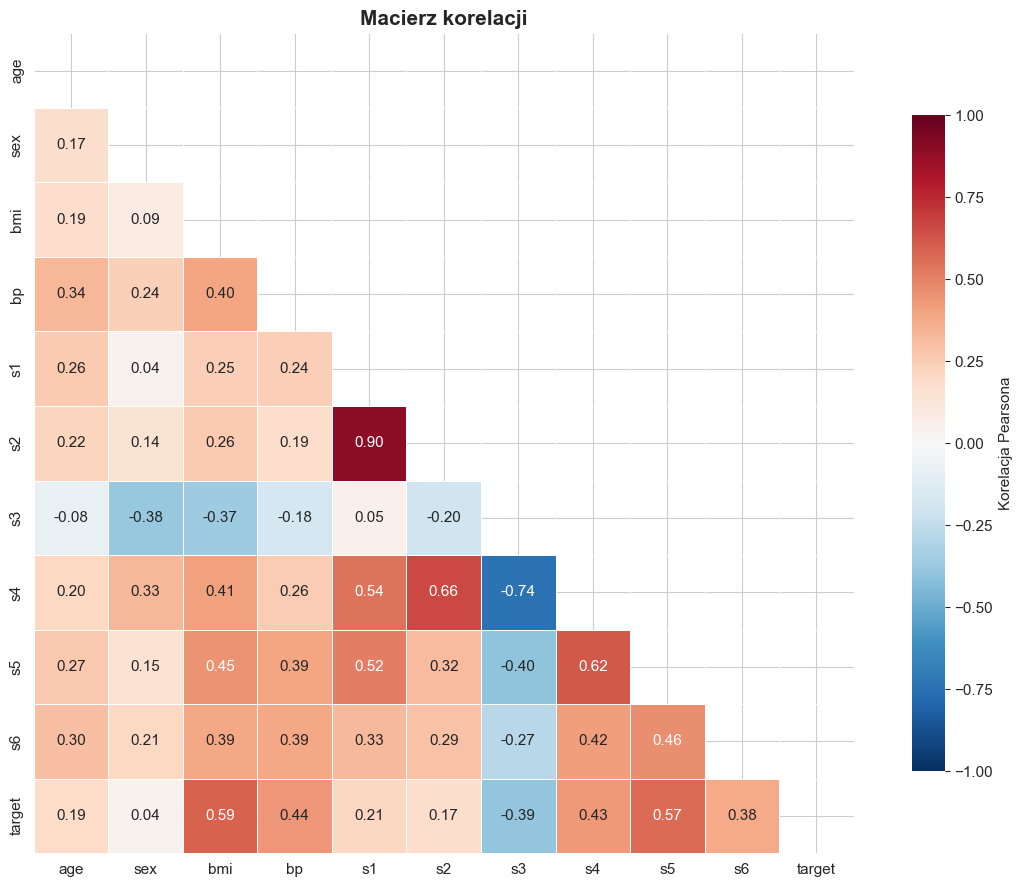

Najsilniej skorelowane cechy z (Y)
   bmi     +0.586  █████████████████
   s5      +0.566  ████████████████
   bp      +0.441  █████████████
   s4      +0.430  ████████████
   s3      -0.395  ███████████
   s6      +0.382  ███████████
   s1      +0.212  ██████
   age     +0.188  █████
   s2      +0.174  █████
   sex     +0.043  █


In [51]:
df_full = X.copy()
df_full["target"] = y

corr = df_full.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Korelacja Pearsona"}, ax=ax)

ax.set_title("Macierz korelacji", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

target_corr = corr["target"].drop("target").abs().sort_values(ascending=False)
print("Najsilniej skorelowane cechy z (Y)")
for feat, val in target_corr.items():
    bar = "█" * int(val * 30)
    print(f"   {feat:6s}  {corr['target'][feat]:+.3f}  {bar}")

# Wnioski: LASSO powinien sobie dobrze poradzić.

### 1.9 Kierunek zależności

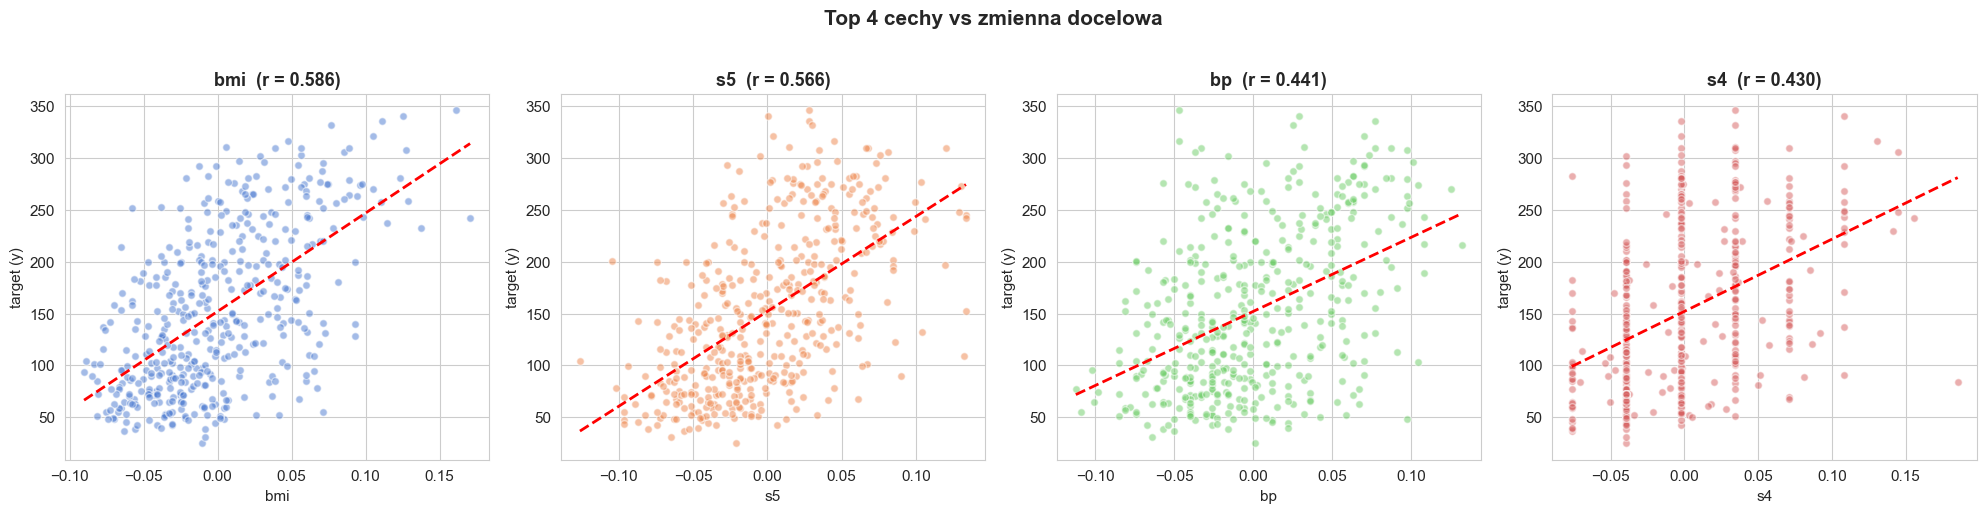

In [52]:
top4 = corr["target"].drop("target").abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, feat in enumerate(top4):
    axes[i].scatter(X[feat], y, alpha=0.5, s=30, color=colors[i], edgecolors="white")
    # linia trendu
    z = np.polyfit(X[feat], y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(X[feat].min(), X[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), "r--", linewidth=2)
    r = corr["target"][feat]
    axes[i].set_title(f"{feat}  (r = {r:.3f})", fontsize=13, fontweight="bold")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("target (y)")

plt.suptitle("Top 4 cechy vs zmienna docelowa", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Wniosek: Zależność liniowa Ridge/LASSO będą działać.

## 2. Podział na zbiór treningowy i testowy

W proporcji **80/20**:
- **Zbiór treningowy (80%)** do trenowania modeli
- **Zbiór testowy (20%)** dla oceny najlepszego modelu

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Zbiór treningowy: {X_train.shape[0]} próbek ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Zbiór testowy:    {X_test.shape[0]} próbek ({X_test.shape[0]/len(X)*100:.0f}%)")

Zbiór treningowy: 353 próbek (80%)
Zbiór testowy:    89 próbek (20%)


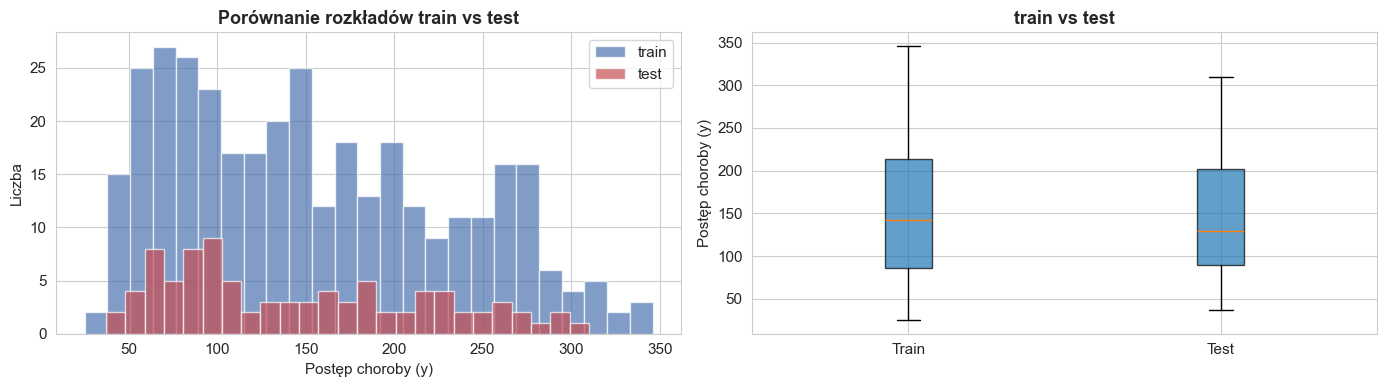

In [54]:
# Sprawdzenie czy rozkład y jest podobny w obu zbiorach
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y_train, bins=25, color="#4C72B0", edgecolor="white", alpha=0.7, label="train")
axes[0].hist(y_test, bins=25, color="#C44E52", edgecolor="white", alpha=0.7, label="test")
axes[0].set_title("Porównanie rozkładów train vs test", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Postęp choroby (y)")
axes[0].set_ylabel("Liczba")
axes[0].legend()

axes[1].boxplot([y_train, y_test], tick_labels=["Train", "Test"], patch_artist=True,
                boxprops=dict(alpha=0.7))
axes[1].set_title("train vs test", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Postęp choroby (y)")

plt.tight_layout()
plt.show()

# Wnioski: Podział 80/20 jest reprezentatywny.

## 3. Walidacja krzyżowa

In [55]:
# Definicja modeli
models = {
    "Ridge (α=1)":          Ridge(alpha=1),
    "Ridge (α=0.01)":       Ridge(alpha=0.01),
    "LASSO (α=1)":          Lasso(alpha=1),
    "LASSO (α=0.01)":       Lasso(alpha=0.01),
    "RandomForest (n=100)": RandomForestRegressor(n_estimators=100, random_state=42),
    "RandomForest (n=200)": RandomForestRegressor(n_estimators=200, random_state=42),
}

results = {}
all_scores = {}

print("=" * 65)
print(f"{'Model':^30s} | {'Średnie R²':^12s} | {'± Std':^10s}")
print("=" * 65)

for name, model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2")
    results[name] = scores.mean()
    all_scores[name] = scores
    print(f"{name:30s} | {scores.mean():^12.4f} | {scores.std():^10.4f}")

print("=" * 65)

            Model              |  Średnie R²  |   ± Std   
Ridge (α=1)                    |    0.4513    |   0.1388  
Ridge (α=0.01)                 |    0.4493    |   0.1440  
LASSO (α=1)                    |    0.4541    |   0.1253  
LASSO (α=0.01)                 |    0.4495    |   0.1435  
RandomForest (n=100)           |    0.3912    |   0.1476  
RandomForest (n=200)           |    0.3977    |   0.1425  


# Wnioski: LASSO (α=1) wygrywa z R² = 0.4541, minimalnie lepszy od reszty modeli liniowych. Finalny model.

### Porównanie wyników

Im dłuższy słupek, tym lepszy model.  

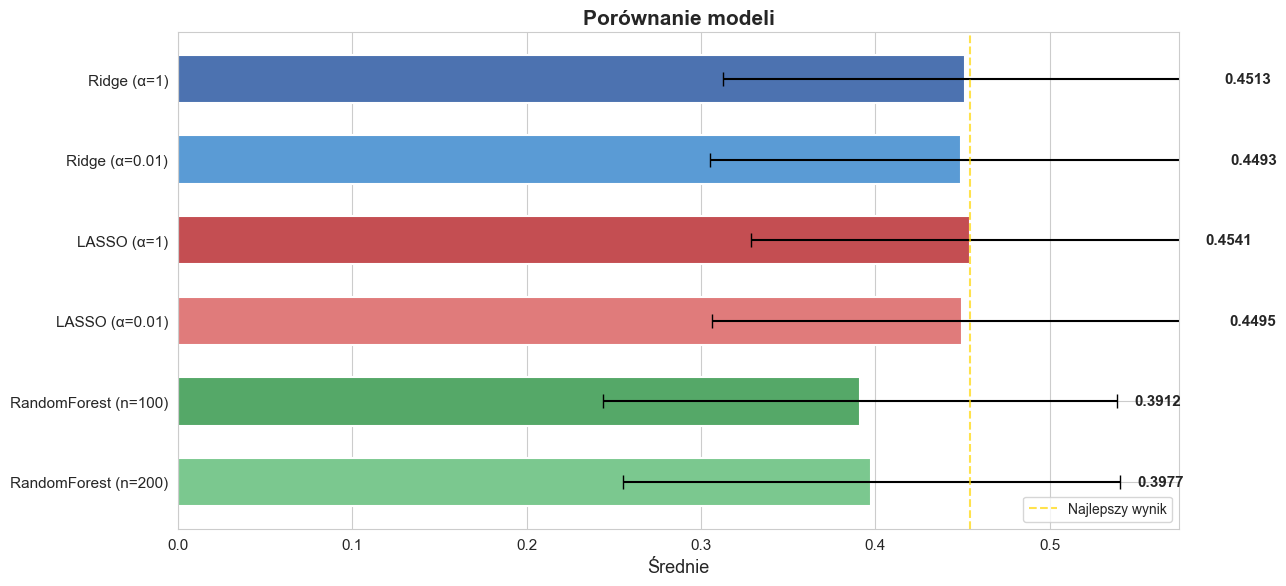

In [56]:
fig, ax = plt.subplots(figsize=(13, 6))

names = list(results.keys())
means = [all_scores[n].mean() for n in names]
stds  = [all_scores[n].std()  for n in names]

colors = ["#4C72B0", "#5A9BD5", "#C44E52", "#E07B7B", "#55A868", "#7BC88F"]
bars = ax.barh(names, means, xerr=stds, capsize=5, color=colors,
               edgecolor="white", linewidth=1.5, height=0.6)

ax.set_xlabel("Średnie", fontsize=13)
ax.set_title("Porównanie modeli", fontsize=15, fontweight="bold")
ax.set_xlim(0, max(means) + 0.12)

for bar, m, s in zip(bars, means, stds):
    ax.text(m + s + 0.01, bar.get_y() + bar.get_height()/2,
            f"{m:.4f}", va="center", fontsize=11, fontweight="bold")

ax.axvline(x=max(means), color="gold", linestyle="--", linewidth=1.5, alpha=0.7, label="Najlepszy wynik")
ax.legend(loc="lower right", fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Rozkład wyników w foldach

Model stabilny powinien mieć wąski boxplot.

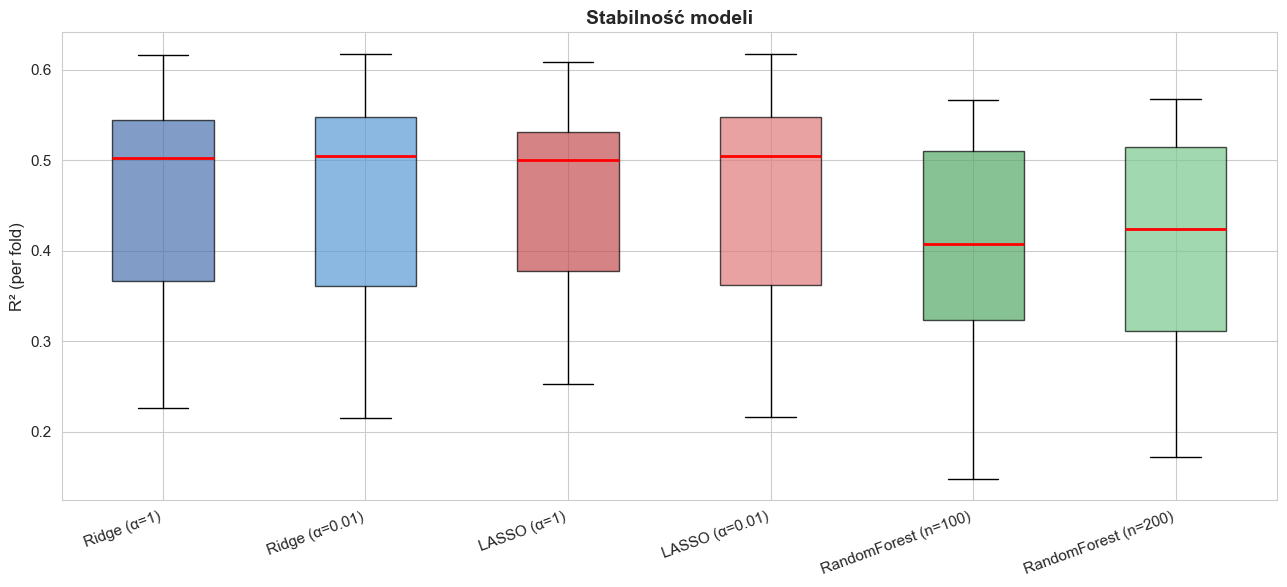

In [57]:
fig, ax = plt.subplots(figsize=(13, 6))

data_to_plot = [all_scores[n] for n in names]
bp = ax.boxplot(data_to_plot, tick_labels=names, patch_artist=True, vert=True,
                medianprops=dict(color="red", linewidth=2))

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("R² (per fold)", fontsize=12)
ax.set_title("Stabilność modeli", fontsize=14, fontweight="bold")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Wnioski: 

- LASSO (α=1) to najbardziej stabilny wynik na foldach. Mało się zmienia.
- Ridge jest ok, ale pudełka trochę szersze niż LASSO.
- Random Forest to najszersze pudełka + najniższe mediany + wąs schodzi nisko Najgorszy i najmniej stabilny.
- LASSO (α=1) = najlepszy średni wynik + najstabilniejszy. Słuszny wybór na model finalny.

## 3b. Wybór najlepszego modelu

In [58]:
best_name = max(results, key=results.get)
best_r2   = results[best_name]
best_std  = all_scores[best_name].std()
print(f"Najlepszy model: {best_name:27s} ║")

Najlepszy model: LASSO (α=1)                 ║


## 4. Trening finalnego modelu

In [59]:
final_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", models[best_name]),
])

# Trening na CAŁYM zbiorze treningowym
final_pipe.fit(X_train, y_train)

# Ewaluacja na zbiorze testowym
r2_test = final_pipe.score(X_test, y_test)

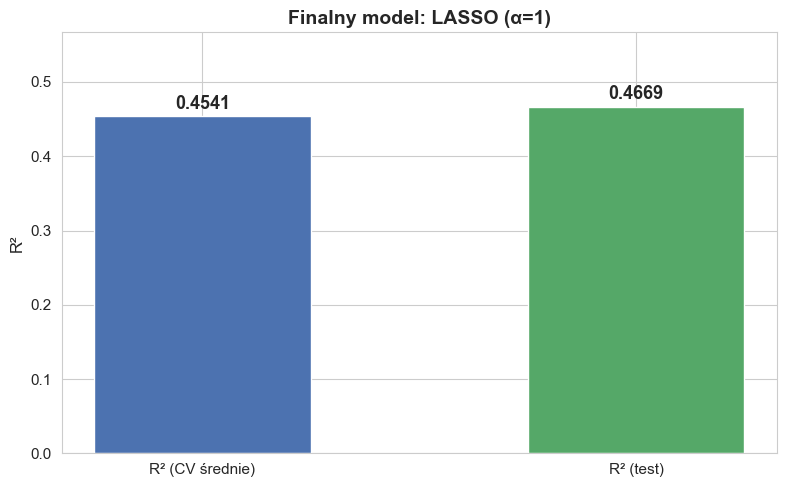

In [60]:
fig, ax = plt.subplots(figsize=(8, 5))

cv_mean = all_scores[best_name].mean()
bars = ax.bar(["R² (CV średnie)", "R² (test)"], [cv_mean, r2_test],
              color=["#4C72B0", "#55A868"], edgecolor="white", width=0.5)

for bar, val in zip(bars, [cv_mean, r2_test]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", fontsize=13, fontweight="bold")

ax.set_ylim(0, max(cv_mean, r2_test) + 0.1)
ax.set_ylabel("R²", fontsize=12)
ax.set_title(f"Finalny model: {best_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Wnioski: Oba słupki prawie tej samej wysokości, więc model nie jest przetrenowany (overfitting). R² (procent wzmienności danych, które model potrafi wytłumaczyć). Na teście nawet minimalnie wyższy niż na CV, co oznacza, że model dobrze generalizuje na nowe, niewidziane wcześniej dane. Wszystko w porządku.

## 5. Analiza reszt (residuals)

Dobry model powinien mieć:
- Reszty **losowo rozrzucone** wokół zera (brak wzorców), a rozrzut reszt nie powinien rosnąć z wartością y

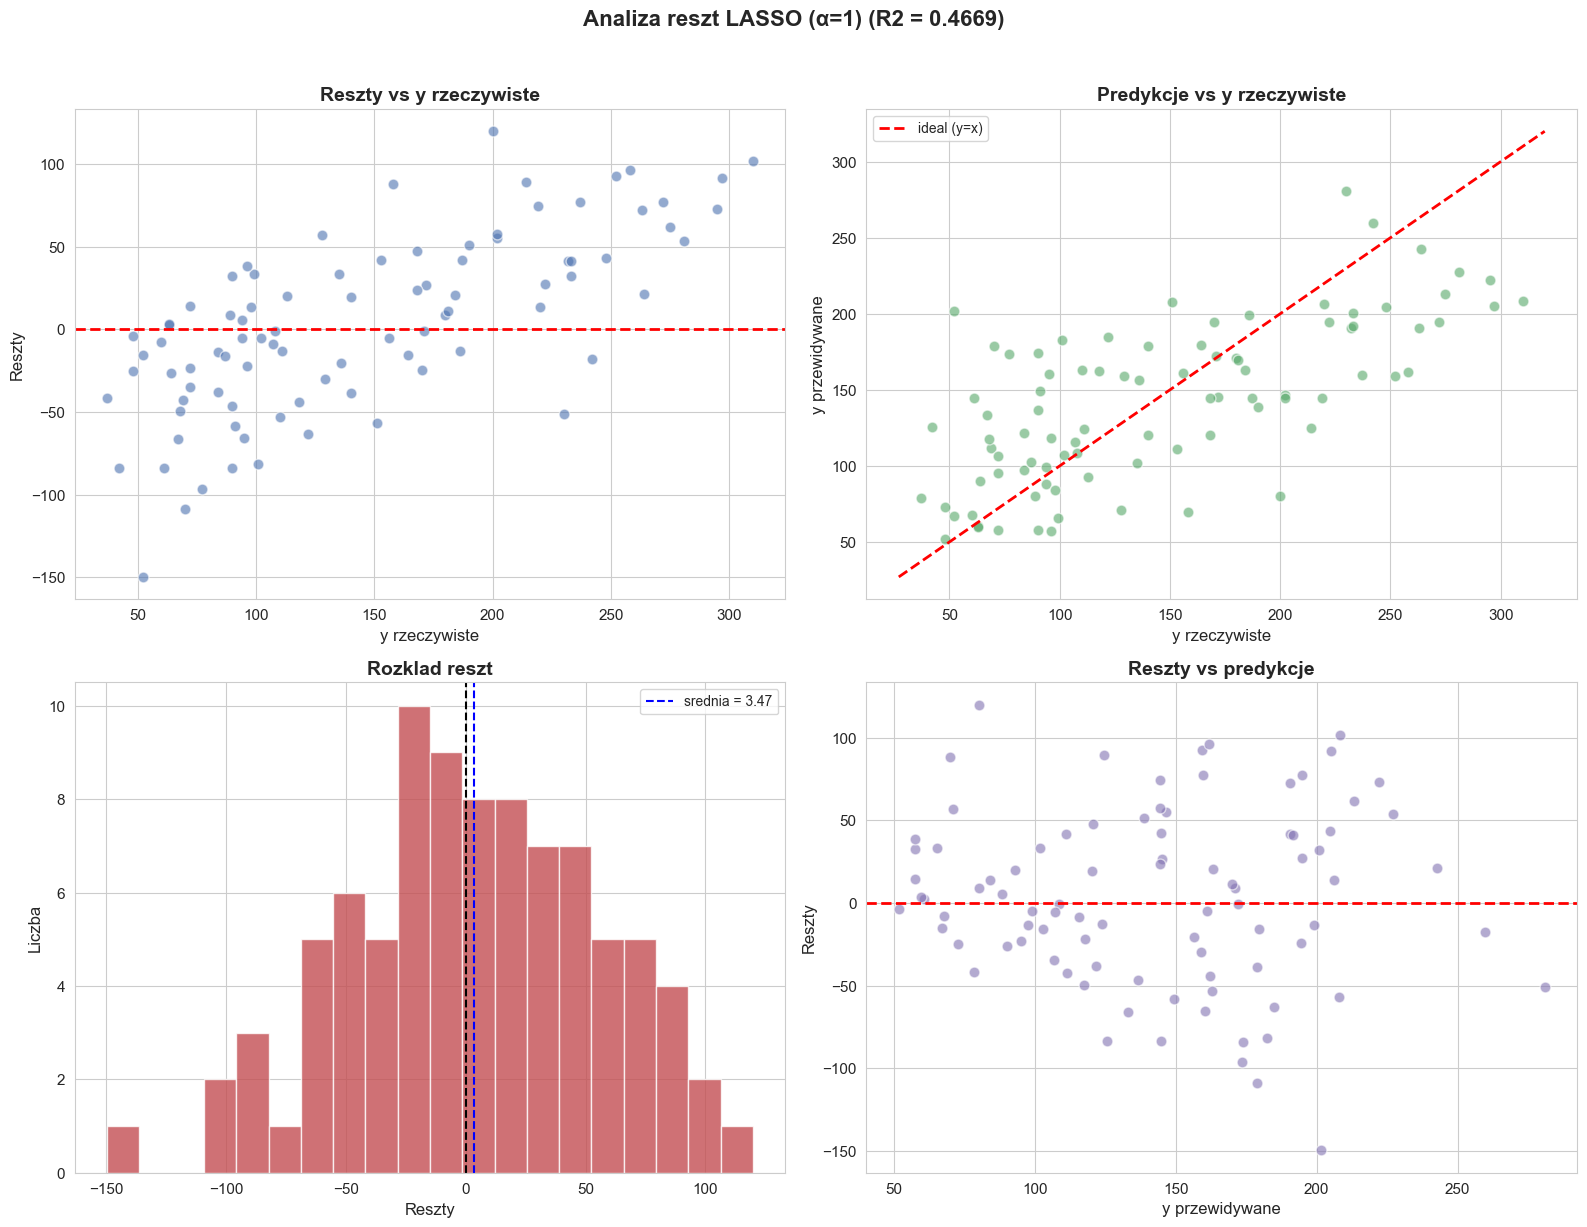

In [61]:
y_pred = final_pipe.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Reszty vs wartosci rzeczywiste
axes[0, 0].scatter(y_test, residuals, alpha=0.6, color="#4C72B0", edgecolors="white", s=60)
axes[0, 0].axhline(0, color="red", linestyle="--", linewidth=2)
axes[0, 0].set_xlabel("y rzeczywiste", fontsize=12)
axes[0, 0].set_ylabel("Reszty", fontsize=12)
axes[0, 0].set_title("Reszty vs y rzeczywiste", fontsize=14, fontweight="bold")

# 2. Predykcje vs wartosci rzeczywiste
axes[0, 1].scatter(y_test, y_pred, alpha=0.6, color="#55A868", edgecolors="white", s=60)
min_val = min(y_test.min(), y_pred.min()) - 10
max_val = max(y_test.max(), y_pred.max()) + 10
axes[0, 1].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="ideal (y=x)")
axes[0, 1].set_xlabel("y rzeczywiste", fontsize=12)
axes[0, 1].set_ylabel("y przewidywane", fontsize=12)
axes[0, 1].set_title("Predykcje vs y rzeczywiste", fontsize=14, fontweight="bold")
axes[0, 1].legend(fontsize=10)

# 3. Histogram reszt
axes[1, 0].hist(residuals, bins=20, color="#C44E52", edgecolor="white", alpha=0.8)
axes[1, 0].axvline(0, color="black", linestyle="--", linewidth=1.5)
axes[1, 0].axvline(residuals.mean(), color="blue", linestyle="--", linewidth=1.5,
                   label=f"srednia = {residuals.mean():.2f}")
axes[1, 0].set_xlabel("Reszty", fontsize=12)
axes[1, 0].set_ylabel("Liczba", fontsize=12)
axes[1, 0].set_title("Rozklad reszt", fontsize=14, fontweight="bold")
axes[1, 0].legend(fontsize=10)

# 4. Reszty vs predykcje
axes[1, 1].scatter(y_pred, residuals, alpha=0.6, color="#8172B2", edgecolors="white", s=60)
axes[1, 1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1, 1].set_xlabel("y przewidywane", fontsize=12)
axes[1, 1].set_ylabel("Reszty", fontsize=12)
axes[1, 1].set_title("Reszty vs predykcje", fontsize=14, fontweight="bold")

plt.suptitle(f"Analiza reszt {best_name} (R2 = {r2_test:.4f})",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Wnioski: Nie ma oznak overfittingu ani systematycznych błędów, model nie faworyzuje jednej strony, łapie ogólny trend, ma tylko losowy outlier.

# Podsumowanie zadania:

- Dane zawierają 442 próbki i 10 cech, bez braków.

- Podzieliłam dane 80/20 na train i test - podział jest ok.

- Przetestowałam 6 modeli (Ridge, LASSO, Random Forest).

- Najlepszy okazał się LASSO z alfa=1 i najbardziej stabilny na foldach.

- Model dobrze generalizuje. 

- Model wyjaśnia ok. 47% zmienności.

---

Najsilniejszą zmienną prognostyczną <u>cukrzycy typu 2</u> (**cukrzyca typu 1 nie jest częścią analizy, trzeba to rozrożnić dla wiarygodności wyników, ten zbiór jej nie definiuje**) okazały się BMI (wskaźnik masy ciała) i trójglicery. Czyli im wyższe BMI i gorszy profil lipidowy, tym szybciej choroba postępuje. To się zgadza. Płeć natomiast praktycznie nie miała wpływu na postęp choroby.

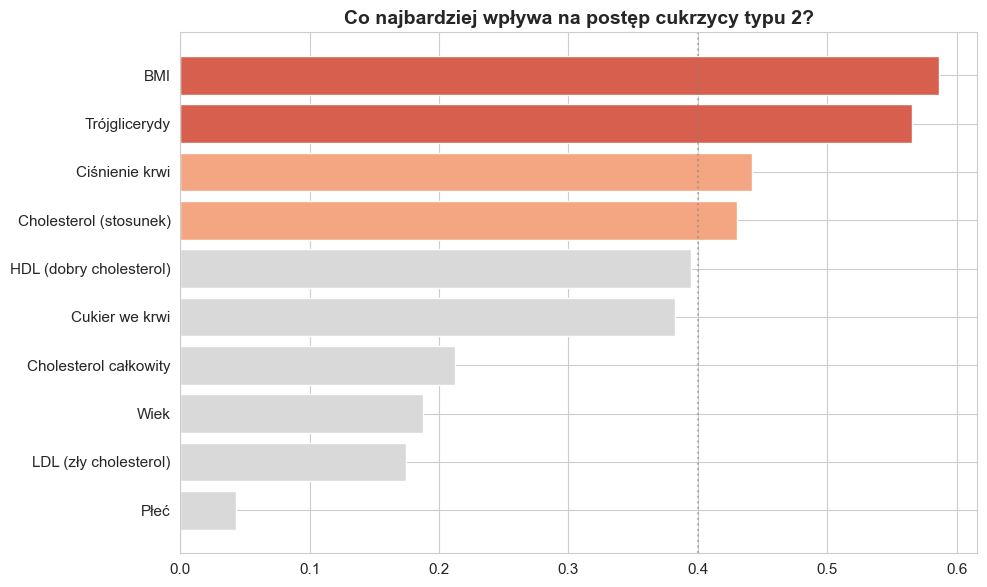

In [69]:
fig, ax = plt.subplots(figsize=(10, 6))

feature_names_pl = {
    "bmi": "BMI", "s5": "Trójglicerydy", "bp": "Ciśnienie krwi",
    "s4": "Cholesterol (stosunek)", "s3": "HDL (dobry cholesterol)", "s6": "Cukier we krwi",
    "s1": "Cholesterol całkowity", "age": "Wiek", "s2": "LDL (zły cholesterol)", "sex": "Płeć"
}

corr_with_target = X.corrwith(y).abs().sort_values(ascending=True)
colors_bar = ["#d9d9d9" if v < 0.4 else "#f4a582" if v < 0.5 else "#d6604d" for v in corr_with_target]

ax.barh([feature_names_pl.get(f, f) for f in corr_with_target.index],
        corr_with_target.values, color=colors_bar, edgecolor="white")
ax.set_title("Co najbardziej wpływa na postęp cukrzycy typu 2?", fontsize=14, fontweight="bold")
ax.axvline(0.4, color="gray", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()